
# DS-A1 · Data Provenance and Measurement Audit
### Dataset: `lerobot/svla_so101_pickplace` (Hugging Face Hub)

**Course**: Data Science (UCAS) — Assessed Task DS-A1  
**Student**: 金莘卉 Jin Xinhui  
**Date**: dataset frozen 2026-09-27; final run 2026-09-30  
**Repository**: https://github.com/lynn3214/ds-a1-data-provenance-audit  
**Submitted version**: tag `v1.0-submission`

---




## 1. Reproducibility setup

We fix the random seed, record package versions, and record the Python version and OS
platform the notebook was run on. The printed output below is also recorded in
`data_card/SOURCE_LICENSE_HASH.md` under "Execution environment", and the full
`pip freeze` is written to `environment_freeze.txt` by the next cell.


In [1]:

import sys, os, platform, random, json, hashlib, subprocess
from pathlib import Path

SEED = 42
random.seed(SEED)

import numpy as np
np.random.seed(SEED)

# Third-party packages used throughout this notebook.
# If any import fails, run:
#   pip install -r ../requirements.txt
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GroupShuffleSplit, ShuffleSplit
from sklearn.metrics import mean_squared_error

from huggingface_hub import HfApi, snapshot_download, hf_hub_download

print("Python       :", sys.version.replace("\n", " "))
print("Platform     :", platform.platform())
print("pandas       :", pd.__version__)
print("numpy        :", np.__version__)
import pyarrow, sklearn, matplotlib, huggingface_hub
print("pyarrow      :", pyarrow.__version__)
print("scikit-learn :", sklearn.__version__)
print("matplotlib   :", matplotlib.__version__)
print("huggingface_hub:", huggingface_hub.__version__)
print("SEED         :", SEED)


Python       : 3.10.18 | packaged by conda-forge | (main, Jun  4 2025, 14:46:00) [Clang 18.1.8 ]
Platform     : macOS-15.5-arm64-arm-64bit
pandas       : 2.3.1
numpy        : 2.2.6
pyarrow      : 25.0.1
scikit-learn : 1.7.1
matplotlib   : 3.10.5
huggingface_hub: 2.0.0
SEED         : 42


In [2]:

# Freeze the full dependency list actually installed in this environment.
# The resulting environment_freeze.txt is committed as part of the reproducibility record.
REPO_ROOT = Path("..").resolve()
freeze_path = REPO_ROOT / "environment_freeze.txt"
with open(freeze_path, "w") as f:
    subprocess.run([sys.executable, "-m", "pip", "freeze"], stdout=f)
print(f"Wrote {freeze_path}")


Wrote /Users/jinshenhui/Documents/UCAS/DS/assignments/ds-a1-lerobot-pickplace-audit/environment_freeze.txt


**Execution order note**: this notebook has a strict top-to-bottom variable dependency
chain (e.g. Section 7 defines `action_arr`/`state_arr`/`JOINT_NAMES` used by Sections
8, 11, 12; Section 9 defines `df_sorted` used by Sections 10, 11, 12). Running cells out
of order, or only running a subset, will raise `NameError`. All randomness is seeded
(`SEED=42`, Section 1; `random_state=SEED` in Section 11's splitters), so a full,
in-order rerun is expected to reproduce identical numeric results every time.


## 2. Question definition

**Stakeholder.** An embodied-AI / robot-learning researcher deciding whether
`lerobot/svla_so101_pickplace` can be used as a benchmark or fine-tuning dataset for an
imitation-learning (behavior cloning) policy, and how to split it for evaluation.

**Testable question.** *Does the recording structure of this dataset (one robot type, one
task string, 50 episodes; environment and operator variation are undisclosed) support a **frame-level** random train/test split
for evaluating an action-prediction baseline, or does it require an **episode-level**
(grouped) split to avoid leakage? How large is the resulting optimism bias if the wrong
split is used?*

**Population.** All possible demonstration trajectories of an SO-100/SO-101 follower arm
performing the single task recorded in `meta/tasks.parquet` ("pink lego brick into the transparent box") under broadly similar lab conditions.

**Sample.** The 50 recorded episodes (11,939 frames total) published in this dataset
snapshot.

**Unit of analysis.** A single timestep / frame (30 fps). The secondary/grouping unit is
the episode (`episode_index`, 0–49).

**Target / response variable.** `action`: the 6-dimensional commanded joint position
vector (`shoulder_pan.pos, shoulder_lift.pos, elbow_flex.pos, wrist_flex.pos,
wrist_roll.pos, gripper.pos`).

**Estimand.** The expected held-out MSE (in the dataset's action units, squared; the unit
is undocumented) of a k-NN regressor mapping `observation.state -> action`, when the
model is applied to a **new episode** that was not used in training. Two estimators of
this quantity are compared:
- $\hat\theta_{frame}$: MSE under a random frame-level 80/20 split (frames from the same
  episode can appear in both train and test).
- $\hat\theta_{episode}$: MSE under a grouped 80/20 split by `episode_index` (an entire
  episode is either fully in train or fully in test).

Because the target is performance on a new episode, $\hat\theta_{episode}$ is the estimator
that matches the estimand, and $\hat\theta_{frame}$ is expected to be biased low if frames
within an episode are strongly dependent. The quantity reported is the gap
$\Delta = \hat\theta_{episode} - \hat\theta_{frame}$ and the ratio
$\hat\theta_{episode} / \hat\theta_{frame}$. A large positive $\Delta$ is *consistent with*
the frame-level split being optimistically biased. That this is *caused by* near-duplicate
temporal neighbors is a hypothesis; it is not tested directly in this notebook (see
Section 15).

**Explicit boundaries.** This audit does **not** attempt to evaluate whether a trained
policy would succeed physically (no success/reward label exists in this dataset — see
Section 8). It only evaluates whether the *evaluation protocol itself* is trustworthy.


## 3. Data-generating process (DGP) and provenance lineage

The diagram below is drawn as an actual matplotlib figure (not a Mermaid block) so it
renders identically in the notebook, the exported PDF, and on GitHub.

**Declared facts, as read from the pinned snapshot's own `meta/info.json`** (not from the
dataset card's embedded copy of it, which is outdated; see below; verified in Section 4-5):
robot_type = `so100_follower`, fps = 30, total_episodes = 50, total_frames = 11939,
total_tasks = 1, codebase_version = `v3.0`. The license (Apache-2.0) is declared in the
dataset card's front matter (`license: apache-2.0`) and in the Hub metadata at the pinned
revision (Section 4).

**Provenance/version finding**: the dataset card (`README.md`) at the pinned commit embeds
a copy of `meta/info.json` that states `"codebase_version": "v2.1"` (line 27 of the card;
the other visible fields there, robot_type, total_episodes and total_frames, match).
The snapshot's actual `meta/info.json` at the same commit declares `codebase_version =
v3.0`, and the on-disk layout matches v3.0: `meta/episodes/` as sharded parquet,
`meta/tasks.parquet`, multi-episode parquet chunks under `data/`, and multi-episode video
files (Section 5 shows several episodes sharing one video file via
`from_timestamp`/`to_timestamp`). At freeze time the Hub HEAD was identical to the pinned
commit (Section 4), so the disagreement is inside a single commit: the card's embedded
snippet is inconsistent with the repository's own metadata files. My planning-stage
assumption of a v2.1-style layout (a single `meta/episodes.jsonl` file, one parquet file
per episode) was consistent with the card. The pinned `meta/info.json` and the files
actually on disk are therefore used as the ground truth for this audit's schema and format
claims, not the dataset card. This illustrates why DS-A1 asks for freezing and hashing the
actual downloaded snapshot instead of relying on its description. Evidence:
`ai_use_log/verification_commands.txt`.


**Provenance gaps (explicitly not resolved by the dataset card — do not silently assume
an answer)**:
- Number of distinct human teleoperators is undisclosed. If a single operator recorded
  all 50 episodes, the action distribution reflects one person's motor style, not a
  population of operators. The dataset card lists both Homepage and Paper as "More Information Needed".
- Whether object placement / lighting / camera position varied across episodes, or was
  held approximately fixed, is undisclosed in the card.
- No ground-truth "task success" or "grasp success" label is included in the schema —
  only the commanded trajectory is recorded, not the outcome.

These gaps are treated as findings, not filled in with assumptions.

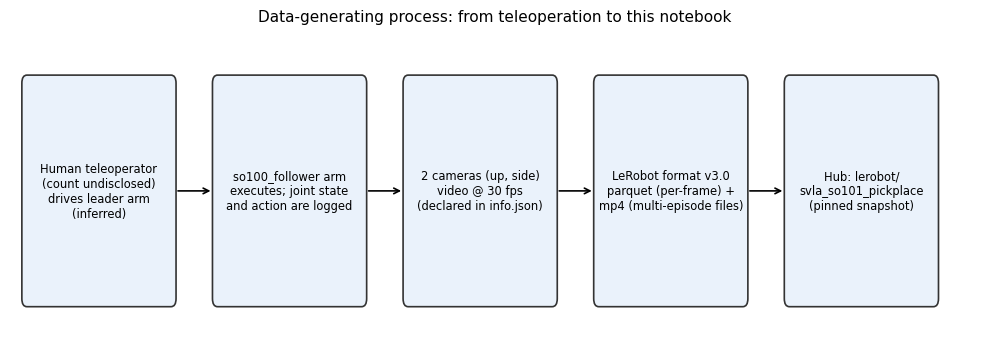

In [3]:

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.axis("off")

stages = [
    "Human teleoperator\n(count undisclosed)\ndrives leader arm\n(inferred)",
    "so100_follower arm\nexecutes; joint state\nand action are logged",
    "2 cameras (up, side)\nvideo @ 30 fps\n(declared in info.json)",
    "LeRobot format v3.0\nparquet (per-frame) +\nmp4 (multi-episode files)",
    "Hub: lerobot/\nsvla_so101_pickplace\n(pinned snapshot)",
]

n = len(stages)
box_w, box_h = 1.7, 1.6
gap = 0.55
x0 = 0.2
y0 = 0.3

for i, text in enumerate(stages):
    x = x0 + i * (box_w + gap)
    rect = mpatches.FancyBboxPatch((x, y0), box_w, box_h,
                                    boxstyle="round,pad=0.06",
                                    linewidth=1.2, edgecolor="#333333",
                                    facecolor="#eaf2fb")
    ax.add_patch(rect)
    ax.text(x + box_w / 2, y0 + box_h / 2, text, ha="center", va="center", fontsize=8.3)
    if i < n - 1:
        ax.annotate("", xy=(x + box_w + gap - 0.05, y0 + box_h / 2),
                     xytext=(x + box_w + 0.05, y0 + box_h / 2),
                     arrowprops=dict(arrowstyle="->", lw=1.2))

ax.set_xlim(0, x0 + n * (box_w + gap))
ax.set_ylim(0, y0 + box_h + 0.4)
ax.set_title("Data-generating process: from teleoperation to this notebook", fontsize=11)
plt.tight_layout()
fig.savefig("../report/dgp_diagram.png", dpi=180)
plt.show()



## 4. Data acquisition and version freezing

We resolve the **exact commit hash** of the dataset repo at the time of first access,
then re-download using that *pinned* revision on every subsequent run, so the analysis
never silently drifts to a newer version of the dataset.

> The commit hash below was resolved on 2026-09-27 and is recorded in
> `data_card/SOURCE_LICENSE_HASH.md`. Every run, including the submitted one, uses that
> pinned hash (`PINNED_REVISION` below); the HEAD lookup in Step 1 is informational only.


In [4]:
REPO_ID = "lerobot/svla_so101_pickplace"
api = HfApi()

# Step 1: look up the current HEAD, purely as a point-in-time record of when this
# audit first observed the repo. This value is NOT used to gate anything below --
# it will drift whenever upstream pushes a new commit, and that drift is expected
# and harmless, not an error.
head_info = api.dataset_info(REPO_ID)
print("Current HEAD commit SHA (informational only, will drift over time):", head_info.sha)
print("Current HEAD last modified:", head_info.lastModified)

# Step 2: the actual frozen version for this audit. Hardcoded once, on first access,
# and never derived from `head_info` again -- this is the real "freeze".
PINNED_REVISION = "f641879e22172be7e8161d5e6c1503c2d2feb657"  # frozen on 2026-09-27

# Step 3: verify the pinned revision itself is a valid, independently resolvable
# commit. This is the actual reproducibility guarantee: it must succeed today, next
# month, or after upstream has moved far past `head_info.sha` above -- because it
# never compares against head_info at all.
pinned_info = api.dataset_info(REPO_ID, revision=PINNED_REVISION)
print("\nPinned revision resolved successfully:", pinned_info.sha)
print("License tag(s) at pinned revision:",
      pinned_info.card_data.get("license") if pinned_info.card_data else None)
assert pinned_info.sha == PINNED_REVISION, (
    "Pinned revision failed to resolve to itself -- check PINNED_REVISION for typos."
)
print("\nUsing pinned revision for all downstream steps:", PINNED_REVISION)

Current HEAD commit SHA (informational only, will drift over time): f641879e22172be7e8161d5e6c1503c2d2feb657
Current HEAD last modified: 2025-09-27 11:25:41+00:00

Pinned revision resolved successfully: f641879e22172be7e8161d5e6c1503c2d2feb657
License tag(s) at pinned revision: apache-2.0

Using pinned revision for all downstream steps: f641879e22172be7e8161d5e6c1503c2d2feb657


In [5]:

DATA_DIR = Path("../data_cache")
DATA_DIR.mkdir(exist_ok=True)

local_dir = snapshot_download(
    repo_id=REPO_ID,
    repo_type="dataset",
    revision=PINNED_REVISION,
    local_dir=DATA_DIR / "svla_so101_pickplace",
)
print("Downloaded to:", local_dir)

local_dir = Path(local_dir)
for p in sorted(local_dir.rglob("*"))[:20]:
    print(p.relative_to(local_dir))
print("... (truncated)")


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

Downloaded to: /Users/jinshenhui/Documents/UCAS/DS/assignments/ds-a1-lerobot-pickplace-audit/data_cache/svla_so101_pickplace
.cache
.cache/huggingface
.cache/huggingface/.gitignore
.cache/huggingface/CACHEDIR.TAG
.cache/huggingface/download
.cache/huggingface/download/.gitattributes.lock
.cache/huggingface/download/.gitattributes.metadata
.cache/huggingface/download/README.md.lock
.cache/huggingface/download/README.md.metadata
.cache/huggingface/download/data
.cache/huggingface/download/data/chunk-000
.cache/huggingface/download/data/chunk-000/file-000.parquet.lock
.cache/huggingface/download/data/chunk-000/file-000.parquet.metadata
.cache/huggingface/download/meta
.cache/huggingface/download/meta/episodes
.cache/huggingface/download/meta/episodes/chunk-000
.cache/huggingface/download/meta/episodes/chunk-000/file-000.parquet.lock
.cache/huggingface/download/meta/episodes/chunk-000/file-000.parquet.metadata
.cache/huggingface/download/meta/info.json.lock
.cache/huggingface/download/meta

In [6]:
for p in sorted((local_dir / "meta").iterdir()):
    kind = "DIR " if p.is_dir() else "FILE"
    print(kind, p.relative_to(local_dir))
    if p.is_dir():
        for sub in sorted(p.rglob("*"))[:5]:
            print("      └─", sub.relative_to(local_dir))

DIR  meta/episodes
      └─ meta/episodes/chunk-000
      └─ meta/episodes/chunk-000/file-000.parquet
FILE meta/info.json
FILE meta/stats.json
FILE meta/tasks.parquet


In [7]:

def sha256_of_file(path, chunk_size=1 << 20):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()

# meta/ 下可能混合了普通文件（如 info.json）和目录（新版格式把 episodes/tasks/stats
# 拆成了按 chunk 存的 parquet 目录）。用 rglob + is_file() 只挑出真正的文件。
meta_files = sorted(p for p in (local_dir / "meta").rglob("*") if p.is_file())
print(f"Found {len(meta_files)} files under meta/ (recursively):")
for p in meta_files:
    print(" ", p.relative_to(local_dir))

files_to_hash = meta_files + sorted((local_dir / "data").rglob("*.parquet"))[:2]

hash_records = []
for fp in files_to_hash:
    hash_records.append({
        "relative_path": str(fp.relative_to(local_dir)),
        "size_bytes": fp.stat().st_size,
        "sha256": sha256_of_file(fp),
    })

hash_df = pd.DataFrame(hash_records)
hash_df.to_csv("../data_card/file_hashes.csv", index=False)
hash_df


Found 4 files under meta/ (recursively):
  meta/episodes/chunk-000/file-000.parquet
  meta/info.json
  meta/stats.json
  meta/tasks.parquet


,relative_path,size_bytes,sha256
0,meta/episodes/chunk-000/file-000.parquet,72560,191998bffd2680c477a4000270cf943bc423ba5fb54ee8...
1,meta/info.json,3401,254909942a6cbfb4692a239e4d0aa5c68ec8eb16f81b65...
2,meta/stats.json,5914,4ae86bed785e0f98914812e87736e216139a22b43cf2b9...
3,meta/tasks.parquet,2246,1040cdef3328ec4376587152647df8e725e80a04210c42...
4,data/chunk-000/file-000.parquet,369943,579ad57e2454359fa9f2c0e83525991bd2e0305b7b2914...


**Verification**: `data_card/file_hashes.csv` was opened and confirmed to contain five
real 64-character hex SHA-256 values (not placeholders). `PINNED_REVISION`
(`f641879e22172be7e8161d5e6c1503c2d2feb657`) and the full hash table were copied into
`data_card/SOURCE_LICENSE_HASH.md`.

**Hash scope**: `file_hashes.csv` covers the five files used in this audit (the four files
under `meta/` and the single `data/` parquet file). The pinned snapshot contains nine files;
the other four (`.gitattributes`, the dataset card `README.md`, and the two video files) were
not hashed here because they are not used in the analysis.

The dataset card `README.md`, which is cited in Section 3, is not in that table; its
SHA-256 was computed separately with `shasum` and is recorded in
`ai_use_log/verification_commands.txt`.

## 5. Loading all episodes into one tidy DataFrame

In this snapshot (LeRobot format v3.0), one parquet file under `data/` may pack several
episodes together, so the number of files is not expected to equal the number of episodes.
We concatenate all data files into a single frame-level table and separately load the
episode-metadata table (`meta/episodes/`), which records each episode's global index
range and per-episode statistics.

In [8]:

info_json = json.loads((local_dir / "meta" / "info.json").read_text())
print(json.dumps(info_json, indent=2)[:1500])


{
  "codebase_version": "v3.0",
  "robot_type": "so100_follower",
  "total_episodes": 50,
  "total_frames": 11939,
  "total_tasks": 1,
  "chunks_size": 1000,
  "fps": 30,
  "splits": {
    "train": "0:50"
  },
  "data_path": "data/chunk-{chunk_index:03d}/file-{file_index:03d}.parquet",
  "video_path": "videos/{video_key}/chunk-{chunk_index:03d}/file-{file_index:03d}.mp4",
  "features": {
    "action": {
      "dtype": "float32",
      "shape": [
        6
      ],
      "names": [
        "shoulder_pan.pos",
        "shoulder_lift.pos",
        "elbow_flex.pos",
        "wrist_flex.pos",
        "wrist_roll.pos",
        "gripper.pos"
      ],
      "fps": 30.0
    },
    "observation.state": {
      "dtype": "float32",
      "shape": [
        6
      ],
      "names": [
        "shoulder_pan.pos",
        "shoulder_lift.pos",
        "elbow_flex.pos",
        "wrist_flex.pos",
        "wrist_roll.pos",
        "gripper.pos"
      ],
      "fps": 30.0
    },
    "observation.images.up

In [9]:
episodes_jsonl = local_dir / "meta" / "episodes.jsonl"
episodes_dir = local_dir / "meta" / "episodes"

if episodes_jsonl.is_file():
    print("Detected legacy format: meta/episodes.jsonl (single file)")
    episodes_meta = pd.read_json(episodes_jsonl, lines=True)
elif episodes_dir.is_dir():
    print("Detected v3 format: meta/episodes/ (directory of parquet shards)")
    ep_parquet_files = sorted(episodes_dir.rglob("*.parquet"))
    print(f"  found {len(ep_parquet_files)} parquet shard(s)")
    episodes_meta = pd.concat(
        [pd.read_parquet(p) for p in ep_parquet_files], ignore_index=True
    )
else:
    raise FileNotFoundError("Neither meta/episodes.jsonl nor meta/episodes/ found.")

print(episodes_meta.shape)
print(episodes_meta.columns.tolist())
episodes_meta.head()

Detected v3 format: meta/episodes/ (directory of parquet shards)
  found 1 parquet shard(s)
(50, 62)
['episode_index', 'data/chunk_index', 'data/file_index', 'dataset_from_index', 'dataset_to_index', 'videos/observation.images.side/chunk_index', 'videos/observation.images.side/file_index', 'videos/observation.images.side/from_timestamp', 'videos/observation.images.side/to_timestamp', 'videos/observation.images.up/chunk_index', 'videos/observation.images.up/file_index', 'videos/observation.images.up/from_timestamp', 'videos/observation.images.up/to_timestamp', 'tasks', 'length', 'stats/action/min', 'stats/action/max', 'stats/action/mean', 'stats/action/std', 'stats/action/count', 'stats/observation.state/min', 'stats/observation.state/max', 'stats/observation.state/mean', 'stats/observation.state/std', 'stats/observation.state/count', 'stats/observation.images.up/min', 'stats/observation.images.up/max', 'stats/observation.images.up/mean', 'stats/observation.images.up/std', 'stats/observ

,episode_index,data/chunk_index,data/file_index,dataset_from_index,dataset_to_index,videos/observation.images.side/chunk_index,videos/observation.images.side/file_index,videos/observation.images.side/from_timestamp,videos/observation.images.side/to_timestamp,videos/observation.images.up/chunk_index,...,stats/index/mean,stats/index/std,stats/index/count,stats/task_index/min,stats/task_index/max,stats/task_index/mean,stats/task_index/std,stats/task_index/count,meta/episodes/chunk_index,meta/episodes/file_index
0,0,0,0,0,303,0,0,0.000000,10.100000,0,...,[151.0],[87.46808941932291],[303],[0],[0],[0.0],[0.0],[303],0,0
1,1,0,0,303,569,0,0,10.100000,18.966667,0,...,[435.5],[76.78704317786953],[266],[0],[0],[0.0],[0.0],[266],0,0
2,2,0,0,569,799,0,0,18.966667,26.633333,0,...,[683.5],[66.39465339920075],[230],[0],[0],[0.0],[0.0],[230],0,0
3,3,0,0,799,982,0,0,26.633333,32.733333,0,...,[890.0],[52.82676089508675],[183],[0],[0],[0.0],[0.0],[183],0,0
4,4,0,0,982,1197,0,0,32.733333,39.900000,0,...,[1089.0],[62.0644825967316],[215],[0],[0],[0.0],[0.0],[215],0,0


In [10]:
parquet_files = sorted((local_dir / "data").rglob("*.parquet"))
print(f"Found {len(parquet_files)} parquet file(s) under data/ "
      f"(note: in this format one file may pack multiple episodes together, "
      f"so this count is NOT expected to equal total_episodes — that's fine).")

frames = [pq.read_table(fp).to_pandas() for fp in parquet_files]
df = pd.concat(frames, ignore_index=True)

n_episodes_seen = df["episode_index"].nunique()
print("Total frames loaded   :", len(df), " | declared total_frames:", info_json["total_frames"])
print("Distinct episodes seen:", n_episodes_seen, " | declared total_episodes:", info_json["total_episodes"])
df.head()

Found 1 parquet file(s) under data/ (note: in this format one file may pack multiple episodes together, so this count is NOT expected to equal total_episodes — that's fine).
Total frames loaded   : 11939  | declared total_frames: 11939
Distinct episodes seen: 50  | declared total_episodes: 50


,action,observation.state,timestamp,frame_index,episode_index,index,task_index
0,"[1.9117647, -99.41053, 99.54483, 74.84063, -48...","[1.9560878, -98.74372, 98.92425, 74.81984, -51...",0.000000,0,0,0,0
1,"[1.9117647, -99.41053, 99.54483, 74.84063, -48...","[1.9560878, -98.74372, 98.92425, 74.81984, -51...",0.033333,1,0,1,0
2,"[1.9117647, -99.41053, 99.54483, 74.84063, -48...","[1.9560878, -98.74372, 98.92425, 74.81984, -51...",0.066667,2,0,2,0
3,"[1.9117647, -99.41053, 99.54483, 74.84063, -48...","[1.9560878, -98.74372, 98.92425, 74.81984, -50...",0.100000,3,0,3,0
4,"[1.9117647, -99.41053, 99.54483, 74.84063, -48...","[1.9560878, -98.74372, 98.92425, 74.81984, -49...",0.133333,4,0,4,0


In [11]:
expected = {"robot_type": "so100_follower", "fps": 30, "total_episodes": 50,
            "total_frames": 11939, "total_tasks": 1, "codebase_version": "v3.0"}
for k, v in expected.items():
    actual = info_json.get(k)
    print(f"{k:18s} expected={v!r:18} actual={actual!r:18} {'OK' if actual == v else 'MISMATCH'}")
print("len(df) =", len(df), "| distinct episodes =", df["episode_index"].nunique())
print("task_index values:", sorted(df["task_index"].unique()))
print("action names:", info_json["features"]["action"]["names"])

robot_type         expected='so100_follower'   actual='so100_follower'   OK
fps                expected=30                 actual=30                 OK
total_episodes     expected=50                 actual=50                 OK
total_frames       expected=11939              actual=11939              OK
total_tasks        expected=1                  actual=1                  OK
codebase_version   expected='v3.0'             actual='v3.0'             OK
len(df) = 11939 | distinct episodes = 50
task_index values: [np.int64(0)]
action names: ['shoulder_pan.pos', 'shoulder_lift.pos', 'elbow_flex.pos', 'wrist_flex.pos', 'wrist_roll.pos', 'gripper.pos']


In [12]:
tasks_df = pd.read_parquet(local_dir / "meta" / "tasks.parquet")
print(tasks_df)

                                          task_index
pink lego brick into the transparent box           0



## 6. Schema audit

Cross-check the *declared* schema in `meta/info.json` (`features` block: dtype and
shape per column) against what pandas/pyarrow actually loaded.


In [13]:

schema_report = []
for col, spec in info_json["features"].items():
    if col not in df.columns:
        schema_report.append({"column": col, "declared_dtype": spec["dtype"],
                               "declared_shape": spec["shape"],
                               "status": "MISSING FROM PARQUET (likely a video-only column)"})
        continue
    sample_val = df[col].iloc[0]
    actual_len = len(sample_val) if hasattr(sample_val, "__len__") else 1
    declared_len = spec["shape"][0] if spec["shape"] else 1
    ok = (actual_len == declared_len)
    schema_report.append({
        "column": col,
        "declared_dtype": spec["dtype"],
        "declared_shape": spec["shape"],
        "actual_pandas_dtype": str(df[col].dtype),
        "actual_vector_len": actual_len,
        "shape_matches": ok,
    })

schema_df = pd.DataFrame(schema_report)
schema_df


,column,declared_dtype,declared_shape,actual_pandas_dtype,actual_vector_len,shape_matches,status
0,action,float32,[6],object,6.0,True,NaN
1,observation.state,float32,[6],object,6.0,True,NaN
2,observation.images.up,video,"[480, 640, 3]",NaN,NaN,NaN,MISSING FROM PARQUET (likely a video-only column)
3,observation.images.side,video,"[480, 640, 3]",NaN,NaN,NaN,MISSING FROM PARQUET (likely a video-only column)
4,timestamp,float32,[1],float32,1.0,True,NaN
5,frame_index,int64,[1],int64,1.0,True,NaN
6,episode_index,int64,[1],int64,1.0,True,NaN
7,index,int64,[1],int64,1.0,True,NaN
8,task_index,int64,[1],int64,1.0,True,NaN


**Schema audit result**: all seven tabular columns (`action`, `observation.state`,
`timestamp`, `frame_index`, `episode_index`, `index`, `task_index`) matched their
`meta/info.json`-declared shape in the first row of each column (`shape_matches = True` for
all seven; only the first row was inspected, not every row). The two
video columns (`observation.images.up`, `observation.images.side`) are, as expected,
absent from the parquet tables — they exist only as separate (multi-episode) `.mp4` files and are
explicitly out of scope for this audit (see Data Dictionary). Note that pandas reports
`action`/`observation.state` as `dtype=object` rather than `float32`; this is expected
and not a mismatch — each cell holds a length-6 array, so pandas can only type the
*column* as `object`; the element dtype of those arrays was not separately verified here. No
undeclared or unexpected columns were found in the parquet files.


## 7. Range and plausibility audit

We expand the 6-dimensional `action` and `observation.state` vectors into individual
columns and inspect their empirical ranges. The physical unit is not documented in meta/info.json; based on the observed ranges (shoulder_pan about -93 to 88, shoulder_lift about -100 to 9, elbow_flex about 13 to 100,
wrist_flex about 34 to 99, wrist_roll about -93 to -20, gripper about 0 to 33), this looks like a normalized position scale rather than raw degrees, but this is not confirmed by the dataset's own documentation. There
is no explicit `min`/`max` contract in `info.json`, so "plausible" here means: finite,
not NaN/inf, and consistent between `action` and `observation.state` (which should track
each other closely for a low-latency follower arm).


In [14]:

JOINT_NAMES = info_json["features"]["action"]["names"]

action_arr = np.stack(df["action"].to_numpy())
state_arr = np.stack(df["observation.state"].to_numpy())

action_wide = pd.DataFrame(action_arr, columns=[f"action.{n}" for n in JOINT_NAMES])
state_wide = pd.DataFrame(state_arr, columns=[f"state.{n}" for n in JOINT_NAMES])

range_report = pd.DataFrame({
    "min": pd.concat([action_wide, state_wide], axis=1).min(),
    "max": pd.concat([action_wide, state_wide], axis=1).max(),
    "mean": pd.concat([action_wide, state_wide], axis=1).mean(),
    "std": pd.concat([action_wide, state_wide], axis=1).std(),
    "n_nonfinite": (~np.isfinite(pd.concat([action_wide, state_wide], axis=1))).sum(),
})
range_report


,min,max,mean,std,n_nonfinite
action.shoulder_pan.pos,-93.455879,88.014709,8.021068,44.564873,0
action.shoulder_lift.pos,-100.000000,8.126316,-55.962349,36.486614,0
action.elbow_flex.pos,12.972235,100.000000,65.255653,29.013208,0
action.wrist_flex.pos,33.531662,99.490013,69.181854,13.238659,0
action.wrist_roll.pos,-92.771675,-20.000000,-53.419933,17.765167,0
action.gripper.pos,0.000000,32.998455,6.848944,8.999420,0
state.shoulder_pan.pos,-92.654694,88.103790,7.987031,44.493618,0
state.shoulder_lift.pos,-98.911224,8.793970,-55.180790,36.828537,0
state.elbow_flex.pos,16.808605,99.372482,66.776299,27.709524,0
state.wrist_flex.pos,34.039848,98.643494,69.252495,13.013702,0


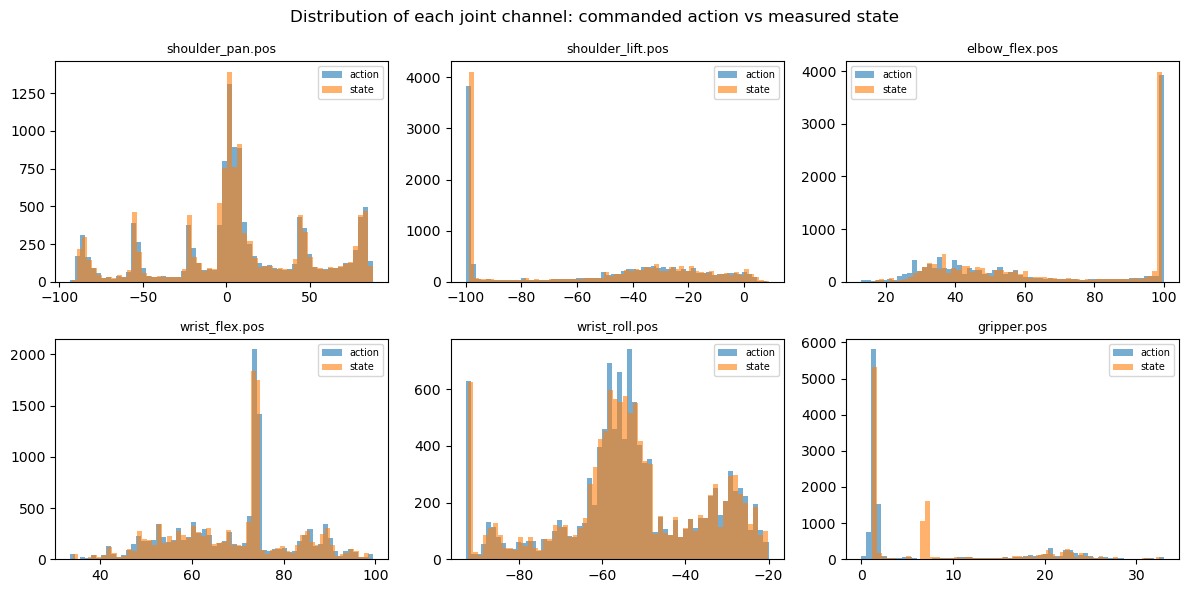

In [15]:

fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=False)
for ax, name in zip(axes.ravel(), JOINT_NAMES):
    ax.hist(action_wide[f"action.{name}"], bins=60, alpha=0.6, label="action")
    ax.hist(state_wide[f"state.{name}"], bins=60, alpha=0.6, label="state")
    ax.set_title(name, fontsize=9)
    ax.legend(fontsize=7)
plt.suptitle("Distribution of each joint channel: commanded action vs measured state")
plt.tight_layout()
fig.savefig("../report/range_histograms.png", dpi=150)
plt.show()


**Range audit result**: no non-finite values were found in any of the 12 columns
(`n_nonfinite = 0` throughout). `action` and `observation.state` track each other
closely for most joints — mean differences are small for `shoulder_pan.pos` (0.034),
`wrist_roll.pos` (0.019) and `wrist_flex.pos` (0.071) — but diverge more for
`elbow_flex.pos` (1.52), `gripper.pos` (1.26) and `shoulder_lift.pos` (0.78). For these three joints
the mean of `action - state` is negative (-1.52, -1.26, -0.78), i.e. commanded values sit
below measured values on average. A signed mean difference cannot distinguish tracking
lag from a constant offset (calibration, steady-state error, or gripper contact when
closing on an object); no lag or cross-correlation analysis was done.

Four boundary values were found in `action` (none in `observation.state`):
`action.shoulder_lift.pos` reaches an exact minimum of `-100.000000`,
`action.elbow_flex.pos` an exact maximum of `100.000000`, `action.wrist_roll.pos` an exact
maximum of `-20.000000`, and `action.gripper.pos` an exact minimum of `0.000000`. The
measured `observation.state` never reaches these exact values (state shoulder_lift min
-98.91, elbow_flex max 99.37, wrist_roll max -20.20, gripper min 1.21). Landing exactly on
round numbers in the command channel is consistent with the commanded action being clipped
at configured limits; the cause (normalized-scale limit, calibration limit, or operator
hardware) was not verified against LeRobot's documentation or source. Anyone using
`action` as a continuous regression target near these bounds should treat those values as
saturated.

The histograms are visibly multi-modal for every joint, with tall, narrow spikes at
`shoulder_lift` near -100 and `elbow_flex` near 100 (roughly 4,000 frames each in the plot),
`gripper` near 1-2 (roughly 5,800 frames) and `wrist_flex` near 73 (roughly 2,000 frames).
These spikes sit at or near the episode-start pose (Section 12), so a large share of frames
is spent near that rest pose. The static-start repeated frames quantified in Section 9 are
only about 3% of all frames (mean leading run 7.18 frames x 50 episodes, about 359 frames),
far fewer than these spike heights, so the spikes must also include near-rest frames
elsewhere in the episode (for example after returning to rest); that was not separately
measured. In addition, `shoulder_pan` shows several separated peaks (around -88, -55, -22,
0, 45 and 85) that lie far from its start-pose values (-4 to 15). This multi-modality is
therefore not explained by the rest pose and may reflect different target or placement
positions across episodes. This was not verified (the videos were not decoded), and it bears
on the "fixed setup" assumption in Section 13.

The `gripper.pos` channel occupies a narrower numeric range (roughly 0-33) than
`shoulder_pan` (span about 181), `shoulder_lift` (about 108) and the other joints (spans
about 66-87). This is consistent with a different mechanism or scale for the gripper, but
the units of all six channels are undocumented in `info.json`.


## 8. Missingness audit

Checked at two levels: (a) null/NaN values in the tabular columns actually present in
the parquet files, and (b) structural "missingness" of a construct the dataset does
**not** provide at all (a success/outcome label) — which is not a NaN in a column, but a
column that was never collected.


In [16]:

tabular_cols = ["timestamp", "frame_index", "episode_index", "index", "task_index"]
na_counts = df[tabular_cols].isna().sum()
na_counts_vecs = pd.Series({
    "action": np.isnan(action_arr).sum(),
    "observation.state": np.isnan(state_arr).sum(),
})
print("NaNs in scalar columns:\n", na_counts)
print("\nNaNs in vector columns (summed over all 6 dims):\n", na_counts_vecs)

has_success_label = any("success" in c.lower() or "reward" in c.lower() or "done" in c.lower()
                         for c in list(df.columns) + list(info_json["features"].keys()))
print("\nDoes the schema include any success/reward/done column?", has_success_label)


NaNs in scalar columns:
 timestamp        0
frame_index      0
episode_index    0
index            0
task_index       0
dtype: int64

NaNs in vector columns (summed over all 6 dims):
 action               0
observation.state    0
dtype: int64

Does the schema include any success/reward/done column? False


**Missingness audit result**: zero NaN values were found across all scalar columns
(`timestamp`, `frame_index`, `episode_index`, `index`, `task_index`) and both vector
columns (`action`, `observation.state`) — 0 missing cells out of 11,939 frames × 17
numeric values per frame (5 scalar columns + 6 action + 6 state channels).

**Structural missingness finding:** despite
zero cell-level missingness, the dataset provides **no outcome label** at all — no
`success`, `reward`, or `done`-at-goal flag (`has_success_label = False`). Every frame
only records *what the operator/arm did*, never *whether the task actually succeeded*.
This is a measurement-construct gap, not a data-quality bug: any claim about "task
performance" made from this dataset alone would require an external annotation step
this dataset does not include.


## 9. Duplicate-frame audit

At the start of many teleoperated recordings the arm is briefly stationary before the
operator begins moving it. We check, per episode, how many **consecutive** frames have
an exactly identical `action` vector to the previous frame (a proxy for "held / static"
frames), and where in the episode they concentrate.


In [17]:

df_sorted = df.sort_values(["episode_index", "frame_index"]).reset_index(drop=True)
action_list = df_sorted["action"].tolist()

is_dup = [False]
for i in range(1, len(action_list)):
    same_episode = df_sorted.loc[i, "episode_index"] == df_sorted.loc[i - 1, "episode_index"]
    same_action = same_episode and np.array_equal(action_list[i], action_list[i - 1])
    is_dup.append(bool(same_action))

df_sorted["is_exact_dup_of_prev"] = is_dup
dup_rate_overall = df_sorted["is_exact_dup_of_prev"].mean()
print(f"Overall fraction of frames that are an exact duplicate of the previous frame: {dup_rate_overall:.2%}")

dup_by_episode = df_sorted.groupby("episode_index")["is_exact_dup_of_prev"].mean()
print("\nPer-episode duplicate-frame rate (head):")
print(dup_by_episode.head(10))


Overall fraction of frames that are an exact duplicate of the previous frame: 14.13%

Per-episode duplicate-frame rate (head):
episode_index
0    0.323432
1    0.120301
2    0.130435
3    0.142077
4    0.144186
5    0.173160
6    0.174107
7    0.157635
8    0.234513
9    0.151961
Name: is_exact_dup_of_prev, dtype: float64


Length of the *leading* run of duplicate frames per episode (head):
episode_index
0    76
1     5
2     0
3     6
4     6
5    10
6     8
7    12
8    19
9     1
Name: is_exact_dup_of_prev, dtype: int64

Median leading run: 3.0 frames
Mean leading run  : 7.18 frames
Episodes with a leading run > 0: 37 / 50


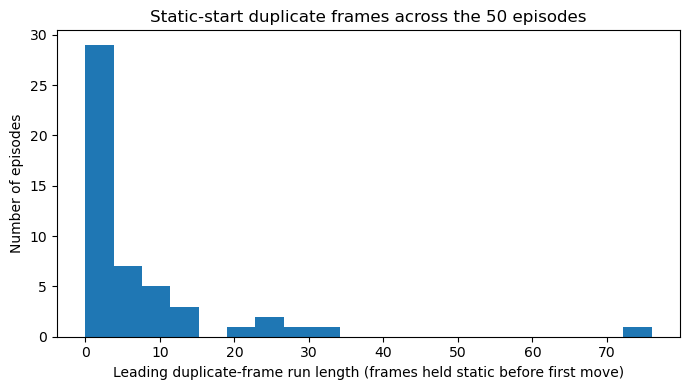

In [18]:

# Where in the episode do duplicates concentrate? (expect: near frame_index 0)
def leading_run_length(is_dup_arr):
    # is_dup_arr[0] is trivially False (no previous frame within this episode),
    # so the *leading run of duplicate frames* starts being meaningful from index 1:
    # count consecutive True values starting right after the (always-False) first frame.
    count = 0
    for v in is_dup_arr[1:]:
        if v:
            count += 1
        else:
            break
    return count

leading_dup_run = (
    df_sorted.groupby("episode_index")["is_exact_dup_of_prev"]
    .apply(lambda s: leading_run_length(s.to_numpy()))
)
print("Length of the *leading* run of duplicate frames per episode (head):")
print(leading_dup_run.head(10))
print("\nMedian leading run:", leading_dup_run.median(), "frames")
print("Mean leading run  :", leading_dup_run.mean(), "frames")
print("Episodes with a leading run > 0:", (leading_dup_run > 0).sum(), "/", len(leading_dup_run))


fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(leading_dup_run, bins=20)
ax.set_xlabel("Leading duplicate-frame run length (frames held static before first move)")
ax.set_ylabel("Number of episodes")
ax.set_title("Static-start duplicate frames across the 50 episodes")
plt.tight_layout()
fig.savefig("../report/duplicate_frames.png", dpi=150)
plt.show()


In [19]:
print(dup_by_episode.describe())

count    50.000000
mean      0.140174
std       0.047673
min       0.059113
25%       0.112323
50%       0.130435
75%       0.153662
max       0.323432
Name: is_exact_dup_of_prev, dtype: float64


**Duplicate-frame audit result**: overall, 14.13% of all 11,939 frames have an
`action` vector identical to the previous frame's within the same episode ("repeated-action"
frames). `observation.state` and the video frames of these rows were not compared, so they
are not necessarily duplicates in the full-row sense. Per-episode,
this rate ranges from 5.91% to 32.34% (mean 14.02%, median 13.04%, std 4.77%) — **every
single episode has a non-trivial duplicate rate, with a floor of ~6%**, not just the
few episodes with unusually long static starts.

Considering only the *leading* run of duplicates at the start of each episode (before
the operator's first move), the median run length is 3 frames (0.1 s at 30 fps) and the
mean is 7.18 frames (0.24 s), with 37 of the 50 episodes (74%) showing at least one
leading duplicate frame; one clear outlier, episode 0, has a 76-frame (2.53 s) static
start. But a mean leading run of 7.18 frames across a ~239-frame average episode
accounts for only ~3% of frames — far short of the observed ~14% overall duplicate
rate. This gap shows that **most duplicate frames are not confined to the episode
start**: they also occur later in the episode; mid-episode pauses and trailing static frames at
the end of an episode are both plausible. Only the leading run was measured, so where the
remaining ~11 percentage points fall was not established.

**Implication**: if a frame-level train/test split is used, both splits will contain a
non-trivial share (~14%, with a per-episode floor of ~6%) of near-identical "held"
frames. Whether these repeated-action frames also have near-identical `observation.state` (which
would make test rows easy to predict from training rows) was not measured here; that is
part of the leakage question in Section 11. Roughly one in seven frames may be an easy,
low-variance prediction target, which could make an evaluation metric look better than it
would on the dynamic portion of the trajectory. This should be
disclosed alongside the leakage result rather than conflated with it.

## 10. Anomaly audit: cross-source consistency

The dataset states each episode's extent in two independent places: the episode-metadata
table (`meta/episodes/`, from which we derive length as `dataset_to_index -
dataset_from_index`) and the frame-level parquet files (row count per `episode_index`).
They should agree exactly. We also check that `timestamp` increases at a constant ~1/30 s
step within each episode (a proxy for dropped/duplicated frames or clock jitter).

In [20]:
# Derive each episode's length from its global index range (dataset_to_index is
# exclusive, matching Python slicing) as an independent cross-check against the parquet
# row counts. (The v3 episode metadata also contains a `length` column, not used here.)
ep = episodes_meta.set_index("episode_index")
declared_lengths = (ep["dataset_to_index"] - ep["dataset_from_index"]).rename("declared_length")
actual_lengths = df_sorted.groupby("episode_index").size().rename("actual_length")

length_check = pd.concat([declared_lengths, actual_lengths], axis=1)
length_check["match"] = length_check["declared_length"] == length_check["actual_length"]
print("Episodes with a length mismatch between meta/episodes (derived) and parquet:")
print(length_check[~length_check["match"]])
print(f"\n{length_check['match'].sum()} / {len(length_check)} episodes match exactly.")

Episodes with a length mismatch between meta/episodes (derived) and parquet:
Empty DataFrame
Columns: [declared_length, actual_length, match]
Index: []

50 / 50 episodes match exactly.


In [21]:

FPS = info_json["fps"]
expected_dt = 1.0 / FPS
tolerance = expected_dt * 0.05  # 5% tolerance

anomalies = []
for ep, g in df_sorted.groupby("episode_index"):
    ts = g.sort_values("frame_index")["timestamp"].to_numpy()
    dt = np.diff(ts)
    bad = np.abs(dt - expected_dt) > tolerance
    if bad.any():
        anomalies.append({"episode_index": ep, "n_irregular_steps": int(bad.sum()),
                           "max_abs_deviation_s": float(np.max(np.abs(dt - expected_dt)))})

anomaly_df = pd.DataFrame(anomalies)
print(f"Episodes with at least one irregular inter-frame timestamp step "
      f"(tolerance = {tolerance*1000:.1f} ms): {len(anomaly_df)} / {episodes_meta.shape[0]}")
anomaly_df.head(10)


Episodes with at least one irregular inter-frame timestamp step (tolerance = 1.7 ms): 0 / 50


""


**Anomaly audit result**: both cross-source consistency checks passed with zero
discrepancies. All 50 episodes' declared frame counts (derived from
`dataset_to_index - dataset_from_index` in the v3 episode metadata) matched the actual
parquet row counts exactly (50/50, 0 mismatches) — no evidence of a mismatch between the episode metadata and the parquet packaging.
Timestamp spacing also stayed within the 5% tolerance (1.7 ms) of the declared 1/30 s
step for every single episode (0/50 episodes with an irregular step). The `timestamp` column
may be a nominal value (frame_index / fps) rather than a measured capture time; if so, this
check confirms internal consistency only and cannot detect real clock jitter or dropped
frames. This was not verified. No anomalies were found under either check; this is reported
as a negative result. Both checks test consistency between metadata and parquet only;
value-level outlier detection (for example frame-to-frame jumps in `action` or
`observation.state`) was not performed.


## 11. Leakage check: frame-level vs episode-level split

We fit a deliberately simple, non-tunable baseline — a k-nearest-neighbors regressor —
to predict `action` from `observation.state`, under two splitting protocols, and compare
held-out MSE. k-NN is chosen because it is simple, has no training-time tuning, and is expected to be
particularly sensitive to near-duplicate neighbors. It is therefore a demonstration of a
sensitive case, not a typical model, and the size of the gap should not be assumed to carry
over to other models.

In [22]:

X = state_arr  # (n_frames, 6)
y = action_arr  # (n_frames, 6)
groups = df_sorted["episode_index"].to_numpy()

def evaluate_split(train_idx, test_idx, k=1):
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X[train_idx], y[train_idx])
    pred = model.predict(X[test_idx])
    return mean_squared_error(y[test_idx], pred)

results = []
for k in (1, 3, 5):
    # (a) frame-level random split -- ignores episode grouping
    frame_splitter = ShuffleSplit(n_splits=5, test_size=0.2, random_state=SEED)
    frame_mses = [evaluate_split(tr, te, k=k) for tr, te in frame_splitter.split(X)]

    # (b) episode-level grouped split -- an episode never appears in both sides
    group_splitter = GroupShuffleSplit(n_splits=5, test_size=0.2, random_state=SEED)
    group_mses = [evaluate_split(tr, te, k=k) for tr, te in group_splitter.split(X, y, groups)]

    results.append({
        "k": k,
        "frame_level_MSE_mean": np.mean(frame_mses),
        "frame_level_MSE_std": np.std(frame_mses),
        "episode_level_MSE_mean": np.mean(group_mses),
        "episode_level_MSE_std": np.std(group_mses),
        "leakage_gap (episode - frame)": np.mean(group_mses) - np.mean(frame_mses),
    })

leakage_report = pd.DataFrame(results)
leakage_report


,k,frame_level_MSE_mean,frame_level_MSE_std,episode_level_MSE_mean,episode_level_MSE_std,leakage_gap (episode - frame)
0,1,5.353241,0.223655,18.529543,2.507665,13.176302
1,3,4.421131,0.138875,14.982736,2.385420,10.561605
2,5,5.268494,0.187832,13.661621,2.415241,8.393126


In [23]:

# Naive "no-op" baseline for context: predict the previous frame's action as this
# frame's action. This calibrates how autocorrelated the series is on its own,
# independent of any train/test split.
prev_action = np.roll(action_arr, shift=1, axis=0)
prev_action[0] = action_arr[0]
same_episode_mask = (df_sorted["frame_index"] > 0).to_numpy()
naive_mse = mean_squared_error(action_arr[same_episode_mask], prev_action[same_episode_mask])
print(f"Naive 'carry previous action forward' baseline MSE (context only): {naive_mse:.4f}")


Naive 'carry previous action forward' baseline MSE (context only): 1.8810


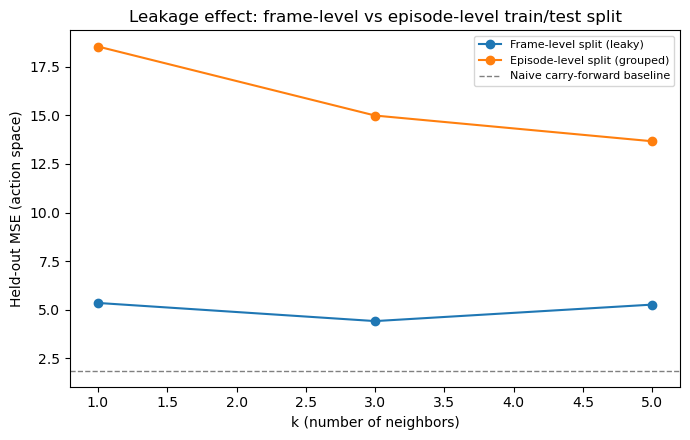

In [24]:

fig, ax = plt.subplots(figsize=(7, 4.5))
xk = leakage_report["k"]
ax.plot(xk, leakage_report["frame_level_MSE_mean"], "o-", label="Frame-level split (leaky)")
ax.plot(xk, leakage_report["episode_level_MSE_mean"], "o-", label="Episode-level split (grouped)")
ax.axhline(naive_mse, color="gray", linestyle="--", linewidth=1, label="Naive carry-forward baseline")
ax.set_xlabel("k (number of neighbors)")
ax.set_ylabel("Held-out MSE (action space)")
ax.set_title("Leakage effect: frame-level vs episode-level train/test split")
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig("../report/leakage_comparison.png", dpi=150)
plt.show()


**Leakage audit result**: at k=1, the frame-level (leaky) split yields a mean held-out
MSE of 5.35, while the episode-level (grouped) split yields 18.53 — a leakage gap of
13.18, meaning the naive frame-level evaluation understates the true error by a factor
of **3.46×**. The same direction and a comparable magnitude hold at k=3 (3.39×) and k=5
(2.59×): episode-level error is consistently 2.6–3.5× higher than frame-level error
across all tested k. This is consistent with the hypothesis in Section 2: a random frame-level split puts frames
from the same episode on both sides of the boundary, and its error estimate is
substantially lower (more optimistic) than the episode-grouped estimate for this model. The
mechanism (near-duplicate temporal neighbors crossing the split) was not tested directly —
no buffered split or nearest-neighbor-distance analysis was run — so it is a plausible
explanation, not an established one. The grouped-split MSE also varies noticeably across
the five splits (std about 2.4-2.5), so the ratios are approximate. The result comes from
one k-NN model on 50 episodes and does not by itself quantify how optimistic a
frame-level benchmark would be for other models. Note also that the declared split in
`info.json` (`train: 0:50`) simply contains all 50 episodes, i.e. the dataset defines no
held-out set, so the evaluation protocol has to be chosen by the user.

A secondary, unexpected finding: the naive "carry the previous action forward" baseline
(MSE = 1.88) actually outperforms the k-NN state→action model under **both** splitting
protocols and all tested k (best k-NN result: 4.42 at k=3, frame-level). This does not
undermine the leakage conclusion — the comparison there is between the same model under
two splits, not between models — but it is worth disclosing honestly: this comparison is not like-for-like. The carry-forward baseline uses the previous
*action* (past label information) as its input, whereas k-NN sees only the current
`observation.state`, and the baseline was computed over all frames rather than on the same
test folds. The result shows how strongly `action` is autocorrelated and only suggests
(does not prove) that a single state snapshot is a weaker predictor than temporal
persistence. Baselines that use the same input as k-NN (for example predicting
`action = observation.state`, or the training mean) were not run.


## 12. Coverage check: how similar are the 50 starting configurations?

A dataset with 50 episodes only supports claims about the specific slice of state-space
it actually covers. We plot each episode's **initial** `observation.state` (frame_index
== 0) projected onto its two most variable dimensions, as a quick, honest look at how
much the arm's starting configuration actually varies across episodes.


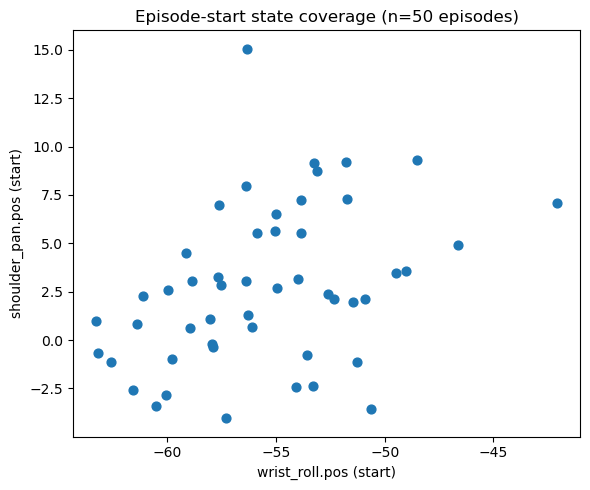

Per-dimension std of episode-start state:
  shoulder_pan.pos    : std = 4.026
  shoulder_lift.pos   : std = 0.267
  elbow_flex.pos      : std = 0.136
  wrist_flex.pos      : std = 0.977
  wrist_roll.pos      : std = 4.411
  gripper.pos         : std = 0.553


In [25]:

start_states = df_sorted[df_sorted["frame_index"] == 0].sort_values("episode_index")
start_arr = np.stack(start_states["observation.state"].to_numpy())

variances = start_arr.var(axis=0)
dim_order = np.argsort(variances)[::-1]
d0, d1 = dim_order[0], dim_order[1]

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(start_arr[:, d0], start_arr[:, d1], s=40)
ax.set_xlabel(f"{JOINT_NAMES[d0]} (start)")
ax.set_ylabel(f"{JOINT_NAMES[d1]} (start)")
ax.set_title(f"Episode-start state coverage (n={len(start_arr)} episodes)")
plt.tight_layout()
fig.savefig("../report/start_state_coverage.png", dpi=150)
plt.show()

print("Per-dimension std of episode-start state:")
for name, v in zip(JOINT_NAMES, start_arr.std(axis=0)):
    print(f"  {name:20s}: std = {v:.3f}")


In [26]:
print("start min:", start_arr.min(axis=0).round(2))
print("start max:", start_arr.max(axis=0).round(2))

start min: [ -4.03 -98.91  98.66  68.21 -63.27   1.21]
start max: [ 15.05 -97.4   99.28  74.82 -42.08   5.3 ]


**Coverage audit result**: episode-start states are tightly clustered, not spread across
each joint's observed operating range. Four of the six joints (`elbow_flex.pos`
std=0.136, `shoulder_lift.pos` std=0.267, `gripper.pos` std=0.553, `wrist_flex.pos`
std=0.977) are essentially constant at episode start, versus a dataset-wide `observation.state` std of 27.7 (elbow_flex), 36.8 (shoulder_lift),
8.4 (gripper) and 13.0 (wrist_flex) (Section 7's range report) — the start-of-episode
spread is roughly 13x (wrist_flex) to 204x (elbow_flex) smaller than the spread across the
whole dataset. Only two joints vary meaningfully at episode start:
`shoulder_pan.pos` (std=4.026, observed range -4.03 to 15.05) and `wrist_roll.pos`
(std=4.411, observed range -63.27 to -42.08), and even these span a
modest band (about 19 and 21 units) relative to their observed dataset-wide ranges of about
181 and 72. The scatter plot
shows the 50 starting configurations spread over a modest cloud, with two visibly separated
episodes (one with shoulder_pan about 15, one with wrist_roll about -42).

This is consistent with, but does not by itself establish, the bias counterexample in
Section 13: the arm starts from nearly the same pose in almost every episode, with only two
of six joints showing any real initial-condition variation. A near-identical start pose is
most likely a consequence of the recording protocol (a fixed rest pose) and does not show
that objects, box position, lighting or operators were fixed; the multi-modal `shoulder_pan`
distribution in Section 7 hints that target positions may vary. A model fit on this sample
has little basis for generalizing to a meaningfully different starting configuration,
because the sample essentially never demonstrates one.


## 13. Bias/measurement counterexample and a prohibited claim

**Counterexample (concrete, falsifiable).** This dataset records a *single task*
("pink lego brick into the transparent box") performed by an *undisclosed number of
teleoperators*, in a setup whose variation across episodes is undisclosed (the metadata
shows one robot type, one pair of camera streams and one task string for all 50 episodes,
`total_tasks = 1`, but says nothing about object, box, lighting or camera-position
variation; the multi-modal `shoulder_pan` distribution in Section 7 hints that target
positions may in fact vary). If the true population of interest is "SO-100/SO-101 pick-and-place
behavior in general" (varied objects, containers, lighting, clutter, operators), this
sample is a convenience sample of that population with unknown coverage of objects,
containers, lighting, clutter and operators, not a random or stratified one. A model fit on it can be expected to fit this specific setup's action distribution
well while telling us little about performance on a different object, a different box
position, or a different operator's motion style — the sample is not exchangeable with
that broader population.

**Measurement counterexample.** `action` is a commanded signal, not an outcome. In this
dataset it is saturated at round-number values on four channels (Section 7) and repeats the
previous frame's value in 14.13% of frames (Section 9). A model that reproduces `action`
well is reproducing the operator's command signal (including its saturation and pauses),
which is not evidence that the task was completed.

**Prohibited claims (do not make any of these claims from this dataset alone):**

1. *"Because a policy trained on `lerobot/svla_so101_pickplace` achieves low held-out
   prediction error, it will generalize to picking up new objects or operating in new
   environments."*
2. *"Because the frame-level held-out error on this dataset is low, a model will perform
   comparably on a new episode."*
3. *"Low action-prediction MSE means the robot completes the pick-and-place task."*

This is not supported: (a) there is no success/outcome label to even define
"generalization" behaviorally (Section 8); (b) the sample covers one task, its episode-start poses are nearly identical (Section 12;
this reflects the recording protocol and does not by itself show that objects or
environments were fixed), and variation in objects, box position, lighting and operators
is undisclosed; (c) low error under a frame-level split can be an optimistic estimate when
frames from the same episode sit on both sides of the split (Section 11, for the k-NN
baseline error was 2.6-3.5x higher under an episode-grouped split). The two added claims
above fail for the same reasons: the first is contradicted by Section 11, the second by
the absence of any success label (Section 8). Any claim about out-of-distribution generalization would require new data
collected under deliberately varied conditions, evaluated with an episode-level (or
condition-level) held-out split.



## 14. Summary of findings

- **Schema**: all 7 tabular columns matched their `meta/info.json`-declared shape
in the first row of each column; the 2 video columns are, as expected, absent from the parquet tables and were
  explicitly excluded from this audit's scope.
- **Range**: no non-finite values anywhere (0/11,939 frames × 12 channels). `action` and
  `observation.state` track closely for most joints (absolute mean difference <0.1 for
  shoulder_pan/wrist_roll/wrist_flex) but differ more for elbow_flex (-1.52), gripper
  (-1.26) and shoulder_lift (-0.78). Four `action` channels sit exactly on round-number
  bounds (`shoulder_lift` min -100, `elbow_flex` max 100, `wrist_roll` max -20, `gripper`
  min 0) while `observation.state` never does, consistent with saturated commands; the
  cause was not verified.
- **Missingness**: 0 NaN cells overall, but a structural gap: no success/reward/done
  label exists anywhere in the schema — outcome cannot be assessed from this dataset
  alone.
- **Duplicates**: 14.13% of all frames are repeated-action frames (`action` identical to the previous frame)
  (per-episode range 5.9%–32.3%, every episode at least 5.9%). Only ~3% of frames are
  attributable to episode-start static holds (median 3, mean 7.18 leading frames per
  episode); the remaining ~11 percentage points occur outside the leading run (location not measured).
- **Anomalies**: 0 discrepancies — all 50 episodes' declared frame counts matched
  parquet row counts exactly, and 0/50 episodes showed timestamp irregularities beyond a
  5% (1.7 ms) tolerance on the declared 1/30 s step. (the timestamp check may be tautological if `timestamp` is nominal; not verified) Reported as a genuine negative
  result.
- **Leakage gap**: substantial and consistent in direction across k=1,3,5 — episode-level
  MSE is 2.6×–3.5× higher than frame-level MSE (13.18 absolute gap at k=1: 5.35 vs
  18.53). For this k-NN baseline, the frame-level split reported error roughly 2.6-3.5x
  lower than the episode-grouped split. (Secondary finding: a naive
  carry-forward baseline, MSE=1.88, beats the k-NN model under every split/k tested —
  disclosed for honesty, does not affect the leakage conclusion.)
- **Coverage / bias**: 4 of 6 joints are essentially constant at episode start
  (std 0.14–0.98, versus a dataset-wide `observation.state` std of 8.4–36.8 for the same
  four joints); only 2 joints vary at episode start, over about 19 (shoulder_pan) and 21
  (wrist_roll) units, well under half of their observed dataset-wide ranges (about 181 and
  72). Episodes start from a near-identical pose (likely the recording protocol's rest
  pose); this alone does not show that objects or environments were fixed.

**Answer to the testable question (Section 2)**: No — for this dataset a random
frame-level split should not be used to evaluate an action-prediction baseline. For the
k-NN baseline it produced error estimates 2.6×–3.5× lower than the episode-grouped split
across k=1,3,5, which is consistent with optimistic bias from temporally adjacent,
near-identical frames of the same episode appearing on both sides of the split (the
mechanism itself was not tested separately). An episode-level (grouped) split is therefore
the appropriate protocol for a trustworthy held-out evaluation. Separately, the dataset's
single-task, near-fixed-start sample (Sections 12–13) means that even a correctly evaluated
model's error says little about generalization beyond this specific setup.

## 15. Limitations and what this audit does not establish

- Pixel content of the two video streams was not decoded or audited (Section 6) — a
  full audit would additionally check for lighting drift, occlusion, and camera
  desync using the `.mp4` files.
- Provenance gaps (operator count, environment variability) were not resolved because
  the dataset card does not disclose them; they are reported as open questions, not
  assumed away.
- The k-NN leakage demonstration is a diagnostic, not a claim about the best possible
  imitation-learning model for this data.
- The leakage mechanism (near-duplicate neighbors) was not tested directly; only one model
  class (k-NN) and five overlapping random splits were used, with no confidence intervals,
  and no same-input trivial baselines were run.
- Range boundary values and the `timestamp` column were not verified against LeRobot's
  documentation or source; units of all channels are undocumented.
- Episode 0 (76-frame static start, 32% repeated-action rate) was not excluded or tested
  for its effect on the results.
- Hashes cover five of the nine files in the pinned snapshot; the video files were neither
  hashed nor decoded.
- Reproducibility evidence (comparison of the pre-edit run with the final run, and
     command-line hash recomputation) is in `ai_use_log/verification_commands.txt`.


## 16. AI use and independent verification

I used Claude (Anthropic) to plan the audit and write the notebook scaffold, and GPT 5.6 Luna as a second reviewer of the finished repository.
Claude was also used to review the repository against the assignment brief and rubric (it
produced issue lists only, no rewriting). 
Neither had
network access to run this notebook against the real data — every number above comes
from my own runs. Running the AI-written code against the actual pinned snapshot
surfaced several real defects that I diagnosed and had fixed: an `IsADirectoryError`
and two wrong format assumptions from the dataset's actual LeRobot v3.0 layout (vs. the
v2.1 layout the webpage suggested during planning), a `cumprod()` logic bug in the
duplicate-run calculation (caught because its output silently contradicted the reported
duplicate rate), a reproducibility-breaking `assert` in the revision-pinning code (found
by GPT's review), a mis-stated physical unit and two mis-read plot values in Sections 7
and 12 (caught by checking the drafted text against `info_json` and the code's own
printed min/max), a column-misaligned CSV in the data dictionary, and a cell placed
before its dependency was defined (only surfaced by a full `Restart & Run All`, not by
running cells individually). Two complete clean reruns produced identical
`key_metrics.json` (to 6 decimal places) and identical file hashes; all five hashed
files were also independently recomputed with command-line `shasum`. 
Full disclosure,
including what AI-drafted text I kept largely as written and why: `ai_use_log/AI_USE_LOG.md`.

In [27]:
key_metrics = {
    "dup_rate_overall": round(float(dup_rate_overall), 6),
    "dup_by_episode_describe": dup_by_episode.describe().round(6).to_dict(),
    "leading_dup_run_median": float(leading_dup_run.median()),
    "leading_dup_run_mean": round(float(leading_dup_run.mean()), 6),
    "episodes_with_leading_run": int((leading_dup_run > 0).sum()),
    "length_match_count": int(length_check["match"].sum()),
    "timestamp_anomaly_episodes": int(len(anomaly_df)),
    "leakage_report": leakage_report.round(6).to_dict(orient="records"),
    "naive_mse": round(float(naive_mse), 6),
    "start_state_std": [round(float(v), 6) for v in start_arr.std(axis=0)],
}
with open("../report/key_metrics.json", "w") as f:
    json.dump(key_metrics, f, indent=2)
print("Wrote ../report/key_metrics.json")

Wrote ../report/key_metrics.json
